In [373]:
import pandas as pd
import numpy as np
import random
random_seed = 42
number_of_customers = 100
mean_age = 59
age_std = 10
min_age, max_age = 19, 75
income_std = 0.3
mean_income = 80000
min_income, max_income = 10000, 250000
random.seed(random_seed)

In [374]:
def generate_random_choices(list_):
    return random.choice(list_)

In [375]:
def generate_weighted_list(df, condition_df, column_name, weighted_list):
    range_ = len(condition_df)
    weighted_list = [random.choices(list(weighted_list.keys()), weights=list(weighted_list.values()))[0] for _ in range(range_)]
    df.loc[condition_df.index, column_name] = weighted_list

In [376]:
customer_ids = [random.randint(10000000, 99999999) for _ in range(number_of_customers)]  # Generate 100 ids
survey_df = pd.DataFrame(customer_ids, columns=['customer_id'])

In [377]:
first_names = ['John', 'Jane', 'Bob', 'Alice', 'David', 'Emily', 'Michael', 'Emma', 'William', 'Olivia',
               'James', 'Isabella', 'Robert', 'Sophia', 'Christopher', 'Ava', 'Joseph', 'Madison', 'Matthew', 'Abigail',
               'Andrew', 'Elizabeth', 'Daniel', 'Mia', 'Anthony', 'Charlotte', 'Joshua', 'Harper', 'Ryan', 'Amelia',
               'Noah', 'Evelyn']
last_names = ['Smith', 'Johnson', 'Williams', 'Brown', 'Jones', 'Miller', 'Davis', 'Garcia', 'Rodriguez', 'Wilson', 'Martinez',
              'Anderson', 'Taylor', 'Thomas', 'Hernandez', 'Moore', 'Martin', 'Jackson', 'Thompson', 'White', 'Lopez', 'Lee', 'Gonzalez']
customer_names = [generate_random_choices(first_names) + " " + generate_random_choices(last_names) for _ in range(number_of_customers)]
survey_df['customer_name'] = customer_names

In [378]:
males = first_names[0::2]
females = first_names[1::2]
survey_df.loc[survey_df['customer_name'].str.split(' ', expand=True)[0].isin(males), 'gender'] = 'Male'
survey_df.loc[survey_df['customer_name'].str.split(' ', expand=True)[0].isin(females), 'gender'] = 'Female'

In [379]:
if mean_age >= 40 and mean_age <= 50:
    ages = np.clip(np.random.normal(loc=mean_age, scale=age_std, size=number_of_customers).astype(int), min_age, max_age)
else:
    factor = np.sqrt(np.log((10**2) / (mean_age**2) + 1))
    mu = np.log(mean_age) - 0.5 * factor**2

    # Generate ages samples with a lognormal distribution and clip to the desired range
    ages = np.clip(np.random.lognormal(mean=mu, sigma=0.5, size=number_of_customers), min_age, max_age)
    ages = [int(number) for number in ages]
survey_df['age'] = ages

In [380]:
min(ages)

19

In [381]:
# Calculate parameters for the lognormal distribution
factor = np.sqrt(np.log((10**2) / (mean_income**2) + 1))
mu = np.log(mean_income) - 0.5 * factor**2

# Generate income samples with a lognormal distribution and clip to the desired range
income = np.clip(np.random.lognormal(mean=mu, sigma=income_std, size=number_of_customers), min_income, max_income)
income = [int(round(number, -3)) for number in income]
survey_df['annual_household_income'] = income

In [382]:
condition_df = survey_df[(survey_df['age'] > 25) & (survey_df['age'] < 60)]
weighted_list = {"Myself":3, "My partner and I":3, "My family with kids":3, "Buying for others":1, "Corporate gifting":2}
generate_weighted_list(survey_df, condition_df, 'who_you_usually_shop_for', weighted_list)

In [383]:
condition_df = survey_df[(survey_df['age'] <= 25)]
weighted_list = {"Myself":5, "My partner and I":3, "My family with kids":2, "Buying for others":1, "Corporate gifting":1}
generate_weighted_list(survey_df, condition_df, 'who_you_usually_shop_for', weighted_list)

In [384]:
condition_df = survey_df[(survey_df['age'] >= 60)]
weighted_list = {"Myself":5, "My partner and I":3, "My family with kids":2, "Buying for others":2, "Corporate gifting":1}
generate_weighted_list(survey_df, condition_df, 'who_you_usually_shop_for', weighted_list)

C:\Users\itunu\AppData\Local\Temp\ipykernel_16412\4188263044.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  seaborn.distplot(ages);


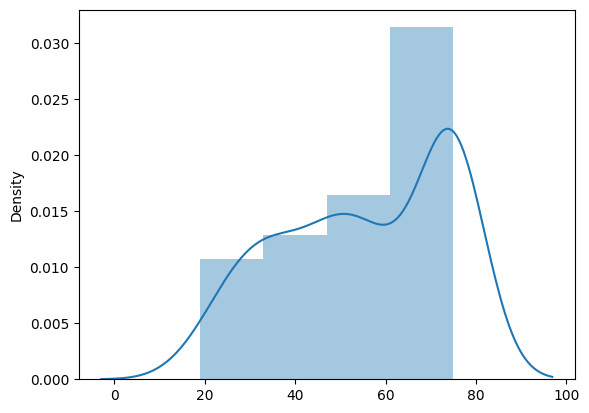

In [385]:
seaborn.distplot(ages);

In [386]:
survey_df.age.value_counts()

age
75    34
50     5
36     4
48     4
39     3
60     3
46     3
29     2
19     2
53     2
58     2
34     2
74     2
26     2
28     2
52     2
55     2
31     2
57     2
61     2
64     1
27     1
45     1
21     1
43     1
68     1
37     1
25     1
70     1
67     1
38     1
24     1
30     1
42     1
62     1
35     1
72     1
54     1
Name: count, dtype: int64

In [364]:
survey_df.age.describe()

count    100.000000
mean      48.280000
std       27.716851
min       19.000000
25%       19.000000
50%       75.000000
75%       75.000000
max       75.000000
Name: age, dtype: float64